<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_4_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from skimage import exposure

In [6]:
def rgb_to_hsi(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_val = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 / (R + G + B + 1e-6)) * min_val

    # Hue
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B)*(G - B)) + 1e-6
    theta = np.arccos(np.clip(num / den, -1, 1))

    H = np.zeros_like(R)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]
    H = H / (2 * np.pi)  # normalize to [0,1]

    return H, S, I

In [7]:
def hsi_to_rgb(H, S, I):
    H = H * 2 * np.pi
    R = np.zeros_like(H)
    G = np.zeros_like(H)
    B = np.zeros_like(H)

    # 0 ≤ H < 2π/3
    idx = (H >= 0) & (H < 2*np.pi/3)
    B[idx] = I[idx] * (1 - S[idx])
    R[idx] = I[idx] * (1 + (S[idx]*np.cos(H[idx])) / np.cos(np.pi/3 - H[idx]))
    G[idx] = 3*I[idx] - (R[idx] + B[idx])

    # 2π/3 ≤ H < 4π/3
    idx = (H >= 2*np.pi/3) & (H < 4*np.pi/3)
    H2 = H[idx] - 2*np.pi/3
    R[idx] = I[idx] * (1 - S[idx])
    G[idx] = I[idx] * (1 + (S[idx]*np.cos(H2)) / np.cos(np.pi/3 - H2))
    B[idx] = 3*I[idx] - (R[idx] + G[idx])

    # 4π/3 ≤ H < 2π
    idx = (H >= 4*np.pi/3) & (H < 2*np.pi)
    H3 = H[idx] - 4*np.pi/3
    G[idx] = I[idx] * (1 - S[idx])
    B[idx] = I[idx] * (1 + (S[idx]*np.cos(H3)) / np.cos(np.pi/3 - H3))
    R[idx] = 3*I[idx] - (G[idx] + B[idx])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    return rgb

In [8]:
def equalize_intensity(I):
    I_eq = exposure.equalize_hist(I)
    return I_eq

/tmp/ipython-input-1379921632.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  rgb_img = imageio.imread("/content/dog.png")


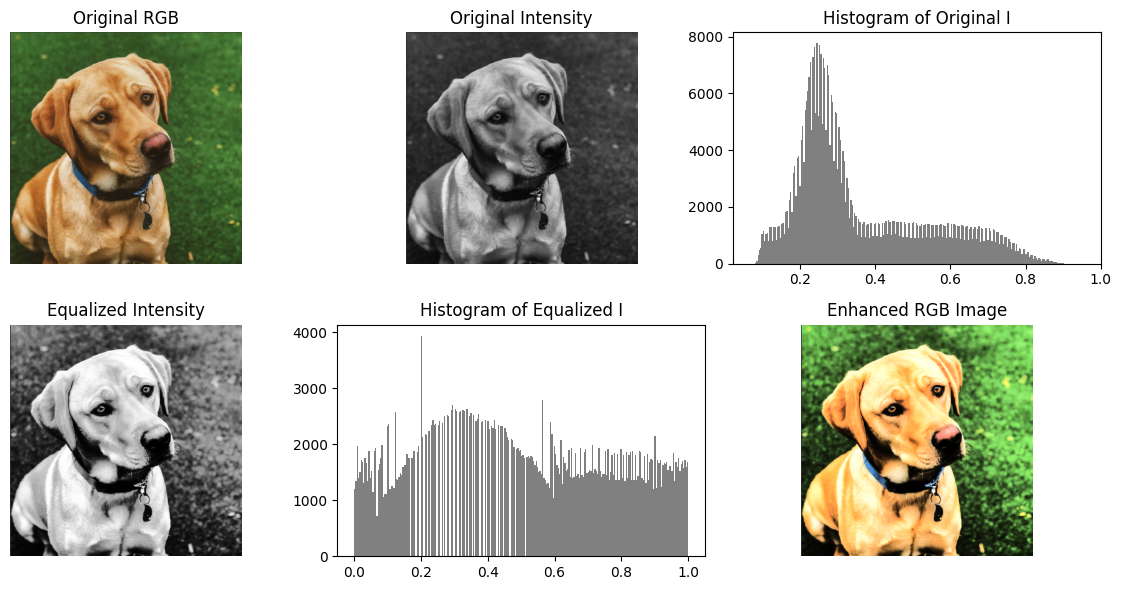

In [9]:
def main():
    try:
        rgb_img = imageio.imread("/content/dog.png")
    except FileNotFoundError:
        from scipy import misc
        rgb_img = misc.face()

    # Convert RGB → HSI
    H, S, I = rgb_to_hsi(rgb_img)

    # Equalize intensity
    I_eq = equalize_intensity(I)

    # Recombine and convert back to RGB
    rgb_enhanced = hsi_to_rgb(H, S, I_eq)

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Original RGB")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(I, cmap="gray")
    plt.title("Original Intensity")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.hist(I.ravel(), bins=256, color='gray')
    plt.title("Histogram of Original I")

    plt.subplot(2, 3, 4)
    plt.imshow(I_eq, cmap="gray")
    plt.title("Equalized Intensity")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.hist(I_eq.ravel(), bins=256, color='gray')
    plt.title("Histogram of Equalized I")

    plt.subplot(2, 3, 6)
    plt.imshow(rgb_enhanced)
    plt.title("Enhanced RGB Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()